In [1]:
import os
import math
import pylab as plt
import seaborn as sns
import matplotlib as mpl

import jupyter_black

jupyter_black.load()

%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [2]:
VERSION = ["research-article_aimrd_f", "research-article_aimrd_f_crop255"]
BASELINE = "baseline_2026-01-23"
start_date = "11-2017"
end_date = "12-2025"

sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

In [3]:
group_frequency_dfs_m = {}
for v, vname in zip(VERSION, ["full", "cropped"]):
    results_path = os.path.join("../../data/results/", BASELINE, v)
    if vname == "full":
        totals_m, totals_y = utils.get_totals(
            results_path, start_date, end_date
        )  # the same for both versions
    group_frequency_dfs_m[vname] = utils.load_freqs(
        data_path=results_path,
        group_prefix="group_",
        start_date=start_date,
        end_date=end_date,
    )

In [4]:
t = group_frequency_dfs_m["full"]["rare_words"]["time"]
n_m = [totals_m[math.floor(y)][round((y % 1) * 12)] for y in t]

for v in ["full", "cropped"]:
    p = group_frequency_dfs_m[v]["rare_words"]["projection"]
    q = group_frequency_dfs_m[v]["rare_words"]["frequency"]
    reg_se = group_frequency_dfs_m[v]["rare_words"]["sdev"]
    se = list(map(utils.se, p, q, n_m, ["regression"] * len(p), reg_se))
    group_frequency_dfs_m[v]["rare_words"]["regression se (ds)"] = se

In [9]:
group_frequency_dfs_m["cropped"]["rare_words"][
    group_frequency_dfs_m["cropped"]["rare_words"]["time"] > 2025.9
]

,section,time,frequency,projection,diff,ratio,sdev,usage,regression se (ds)
582,full,2025.916667,0.921803,0.868680,0.053124,1.061154,0.004130,0.404534,0.026009
583,methods,2025.916667,0.931470,0.899571,0.031900,1.035461,0.004165,0.317632,0.035976
584,discussion,2025.916667,0.973105,0.916790,0.056315,1.061426,0.003693,0.676779,0.022370
585,results,2025.916667,0.893760,0.804549,0.089211,1.110883,0.004892,0.456435,0.019464
586,introduction,2025.916667,0.933002,0.835199,0.097803,1.117101,0.005562,0.593459,0.019175
587,abstract,2025.916667,0.959897,0.879944,0.079953,1.090861,0.004456,0.665961,0.019024


In [5]:
plt.style.use("../../src/mpl_style_2.txt")
mpl.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams.update(
    {
        "font.size": 5,  # base size
        "axes.labelsize": 5,  # x/y labels
        "axes.titlesize": 6,  # subplot titles
        "xtick.labelsize": 4,
        "ytick.labelsize": 4,
        "legend.fontsize": 5,
        "legend.title_fontsize": 5,
    }
)

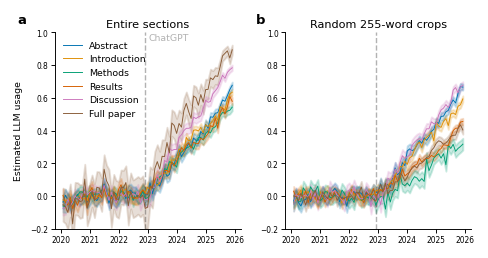

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3.5, 1.8), layout="constrained")

for ax, v in zip(axs, ["full", "cropped"]):
    df = group_frequency_dfs_m[v]["rare_words"]
    df = df[df["time"] >= 2020]

    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(
        data=df,
        x="time",
        y="usage",
        hue="section",
        palette=colors,
        hue_order=sections,
        ax=ax,
        linewidth=0.5,
    )

    for sec in df["section"].unique():
        ax.fill_between(
            df[df["section"] == sec]["time"],
            df[df["section"] == sec]["usage"]
            - df[df["section"] == sec]["regression se (ds)"],
            df[df["section"] == sec]["usage"]
            + df[df["section"] == sec]["regression se (ds)"],
            alpha=0.2,
            color=colors[sec],
        )
    ax.set_xlabel(None)
    ax.set_xticks(range(2020, 2027))
    ax.set_ylim([-0.2, 1])

handles, _ = axs[0].get_legend_handles_labels()
axs[0].legend(
    handles,
    ["Abstract", "Introduction", "Methods", "Results", "Discussion", "Full paper"],
)
axs[1].get_legend().remove()
axs[0].set_ylabel("Estimated LLM usage")
axs[1].set_ylabel(None)
axs[0].text(
    x=2022 + (11 / 12) + 0.1,
    y=0.95,
    s="ChatGPT",
    color="black",
    alpha=0.3,
    horizontalalignment="left",
)
axs[0].set_title("Entire sections")
axs[1].set_title("Random 255-word crops")


for ax, letter in zip(axs, ["a", "b"]):
    if letter == "a":
        x = -0.2
    else:
        x = -0.16
    y = 1.1
    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=7,
        fontweight="bold",
        va="top",
    )

fig.savefig(
    "curves.pdf",
    format="pdf",
    bbox_inches="tight",
)